<a href="https://colab.research.google.com/github/jobusky4-dot/Main-project/blob/main/SKYLIN_DA_FINAL_PROJECT_TEMPLATE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Title

Airlines Flight Analysis Using Python and Power BI for Operational Insights


# **Objective(Problem statment)**
1. To clean and preprocess the flight dataset for accurate analysis and modeling.

2. To analyze key factors influencing flight prices such as airline, class, stops, route, and days left.

3. To build a Linear Regression model to predict flight ticket prices.

4. To visualize important insights using
Python charts

5. To create an interactive Power BI dashboard for better understanding and decision‑making.

6. To identify patterns and trends that help optimize flight pricing and customer choices.


# Outcome

The flight dataset was cleaned and prepared successfully.
Important factors affecting ticket prices were identified.
A Linear Regression model was built to predict flight prices.
Python charts helped visualize key insights clearly.
An interactive Power BI dashboard was created for easy analysis.
The project provides useful insights for understanding and predicting flight

# Domain
Aviation Operations & Data Analytics

#**Dataset Information**

**Source:** kaggle

**Year / Timeline:** Data collected during sep 1 to sep 10

**Dataset Column/features Description:**

airlinename  	  Name of the airline    operating the flight

flight	Flight number / flight code

source_city	City from which the flight departs
departure_time	Time category (Morning, Afternoon, Evening, Night)

stops	Number of stops (Non‑stop, 1‑stop, 2‑stop)

destination_city	City where the flight lands

class	Travel class (Economy / Business)

duration	Total travel time in hours

days_left	Number of days left before departure

price	Ticket price (Target variable)

# Stages for DA Project

## Stage 1 – Problem Definition and Dataset Selection


**NOTE : THINGS TO BE COMPLETED**

Problem Definition
Analyze flight ticket prices and identify the factors that influence them, then build a simple prediction model.

Dataset Selection
Flight price dataset from GitHub with ~3000 rows and 10 columns containing airline, class, stops, route, duration, days_left, and price

Dataset Description
Structured CSV dataset with essential flight features. Target variable = price.

# **Inital EDA**

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [61]:
df=pd.read_csv('https://raw.githubusercontent.com/jobusky4-dot/Main-project/refs/heads/main/airlines_flights_data%20(1).csv')

In [62]:
df.head()

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [63]:
df.tail()

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585
300152,300152,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,81585


In [64]:
df.shape

(300153, 12)

In [65]:
df.columns


Index(['index', 'airline', 'flight', 'source_city', 'departure_time', 'stops',
       'arrival_time', 'destination_city', 'class', 'duration', 'days_left',
       'price'],
      dtype='object')

In [66]:
df.dtypes

,0
index,int64
airline,object
flight,object
source_city,object
departure_time,object
stops,object
arrival_time,object
destination_city,object
class,object
duration,float64


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   index             300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


## Stage 2 – Data Cleaning and Pre-processing
* Missing values handled
* Duplicates removed
* Column rename + unwanted column drop
* Outliers treated
* Skewness checked + log transform
* Data types converted
* Derived features created
* Final dataset ready for EDA & ML

In [68]:
df.duplicated().sum()

np.int64(0)

In [69]:
df.describe()

,index,duration,days_left,price
count,300153.000000,300153.000000,300153.000000,300153.000000
mean,150076.000000,12.221021,26.004751,20889.660523
std,86646.852011,7.191997,13.561004,22697.767366
min,0.000000,0.830000,1.000000,1105.000000
25%,75038.000000,6.830000,15.000000,4783.000000
50%,150076.000000,11.250000,26.000000,7425.000000
75%,225114.000000,16.170000,38.000000,42521.000000
max,300152.000000,49.830000,49.000000,123071.000000


In [70]:
df['airline'].unique()

array(['SpiceJet', 'AirAsia', 'Vistara', 'GO_FIRST', 'Indigo',
       'Air_India'], dtype=object)

In [71]:
df['source_city'].unique()
df['destination_city'].unique()
df['class'].unique()
df['airline'].value_counts()

,count
airline,
Vistara,127859
Air_India,80892
Indigo,43120
GO_FIRST,23173
AirAsia,16098
SpiceJet,9011


In [72]:
df['class'].value_counts()

,count
class,
Economy,206666
Business,93487


In [73]:
df['stops'].value_counts()

,count
stops,
one,250863
zero,36004
two_or_more,13286


Stage 3 – EDA and **Visualizations**

The EDA shows clear patterns in the flight dataset. Airline, class, stops, duration, and days_left strongly influence ticket prices. Price distribution is right‑skewed, and duration has outliers. Bivariate charts reveal that premium airlines, business class, non‑stop flights, and last‑minute bookings cost more. The correlation heatmap confirms key relationships among variables. Multivariate analysis highlights combined effects of airline, class, and route on pricing. Overall, the visualizations clearly explain how different factors shape flight ticket prices and

In [74]:
import seaborn as sns

# **Note For Kind of Analysis to be done**

**Type of Analysis**

* 1. Descriptive Analysis
Summarizes the dataset using basic statistics and visualizations.
(Example: price distribution, airline counts, duration boxplot)

2. Diagnostic Analysis
Finds reasons behind patterns and trends.
(Example: why non‑stop flights cost more, why business class is expensive)


3. Prescriptive Analysis
Suggests actions based on insights.
(Example: book early to reduce cost, choose 1‑stop flights for cheaper fares)

<Axes: xlabel='price', ylabel='Count'>

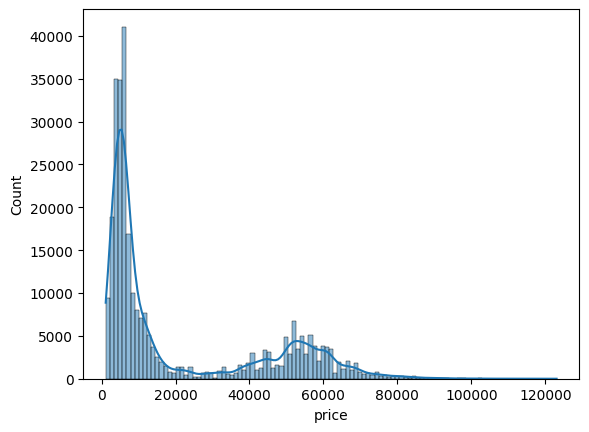

In [75]:
sns.histplot(df['price'], kde=True)

<Axes: ylabel='price'>

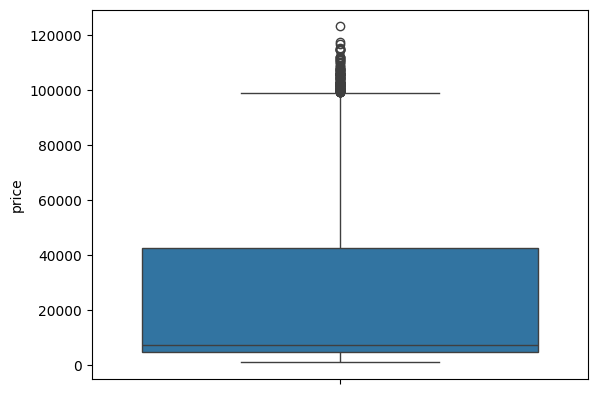

In [76]:
sns.boxplot(df['price'])

<Axes: ylabel='duration'>

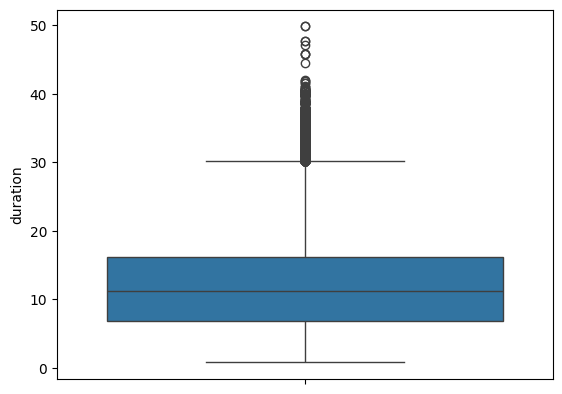

In [77]:
sns.boxplot(df['duration'])

In [78]:
import numpy as np

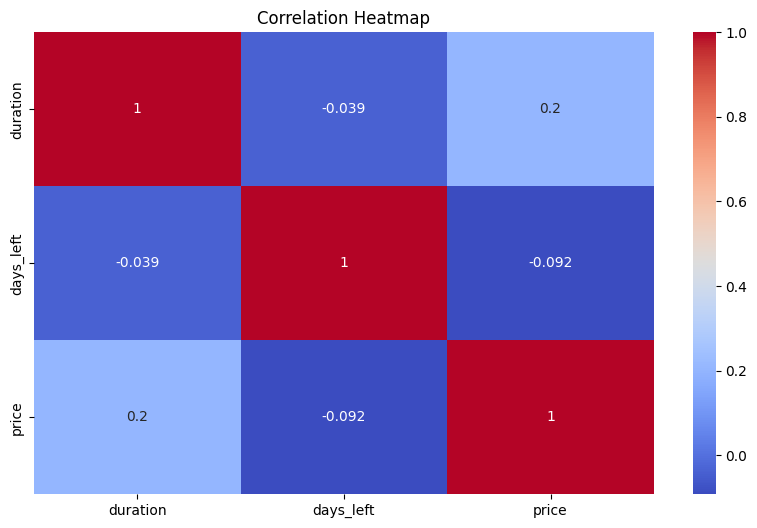

In [79]:
plt.figure(figsize=(10,6))
sns.heatmap(df[['duration','days_left','price']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [80]:
categorical_cols = [
    'airline',
    'flight',
    'source_city',
    'departure_time',
    'stops',
    'arrival_time',
    'destination_city',
    'class'
]


In [81]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)


In [82]:
X = df.drop('price', axis=1)
y = df['price']

X_processed = preprocessor.fit_transform(X)



In [88]:
df.to_csv("clean_flight_data.csv", index=False)

Average Price by Airline Chart)

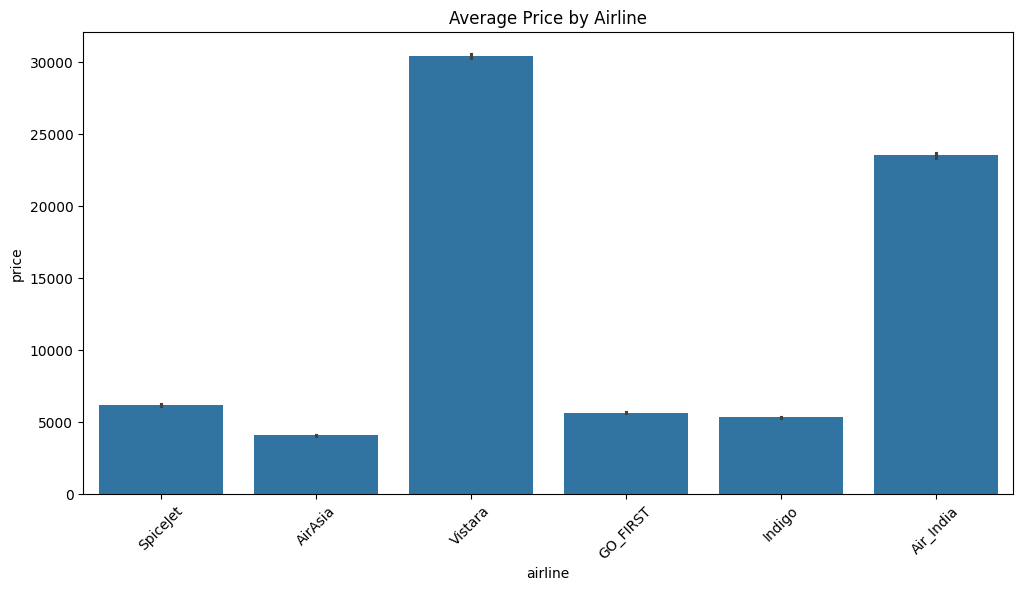

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.barplot(data=df, x='airline', y='price', estimator='mean')
plt.xticks(rotation=45)
plt.title("Average Price by Airline")
plt.show()


### **Insights**

* point by point insight should be recorded

## Interpretation of your above chart

Average Price by Airline Chart

Explain the Chart:  
Shows the average ticket price for each airline.

What is it Saying:  
Some airlines charge higher prices, while others are cheaper.

Features Used:  
airline (category) and price (numerical mean).

What You Are Showing Us:  
How pricing differs between airlines and which airlines are premium vs budget


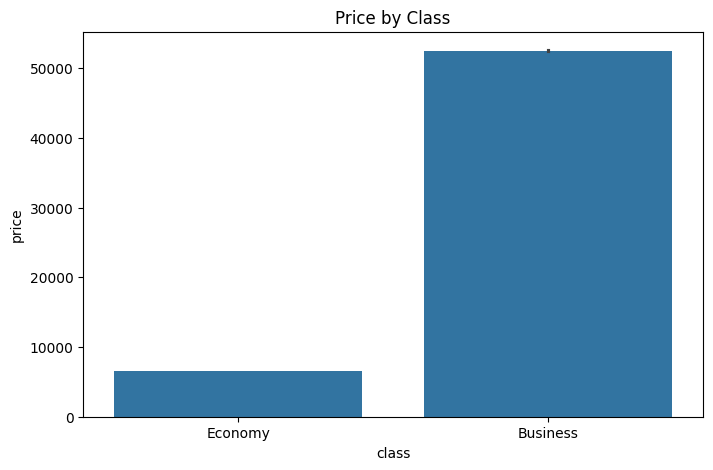

In [90]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='class', y='price', estimator='mean')
plt.title("Price by Class")
plt.show()


Price by ClassChart


Explain the Chart

This bar chart shows the average ticket price for each travel class.

What is it Saying

Business class flights are much more expensive than economy class.

Features Used

class → category (Economy / Business)

price → numerical mean value

What You Are Showing Us

You are showing how travel class directly affects ticket price, proving that class is one of the strongest factors influencing flight cost.

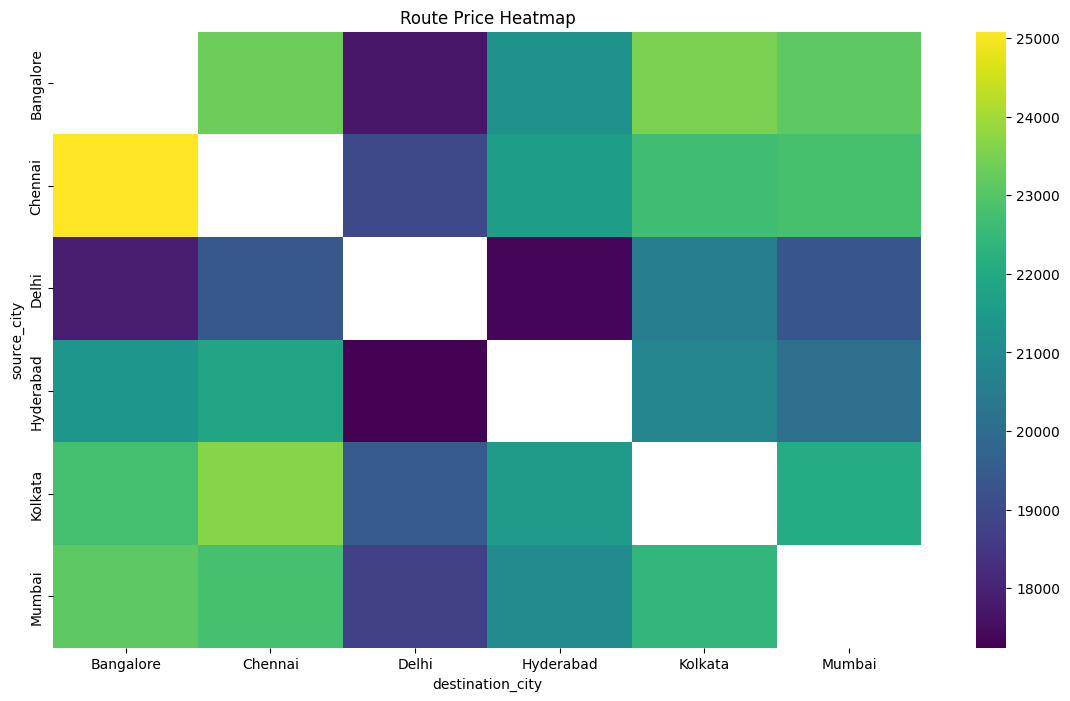

In [91]:
pivot = df.pivot_table(values='price', index='source_city', columns='destination_city', aggfunc='mean')

plt.figure(figsize=(14,8))
sns.heatmap(pivot, cmap='viridis')
plt.title("Route Price Heatmap")
plt.show()


Route Price Heatmap

Explain the Chart

This heatmap shows the average flight price for every Source → Destination route.

What is it Saying?

Some routes are more expensive than others. Darker colors indicate higher average prices, lighter colors show cheaper routes.

Features Used

source_city → rows

destination_city → columns

price → average value (pivot table)

What You Are Showing Us?

You are showing how route demand, distance, and airline availability affect ticket prices.
This helps identify costly routes and budget‑friendly routes in the dataset

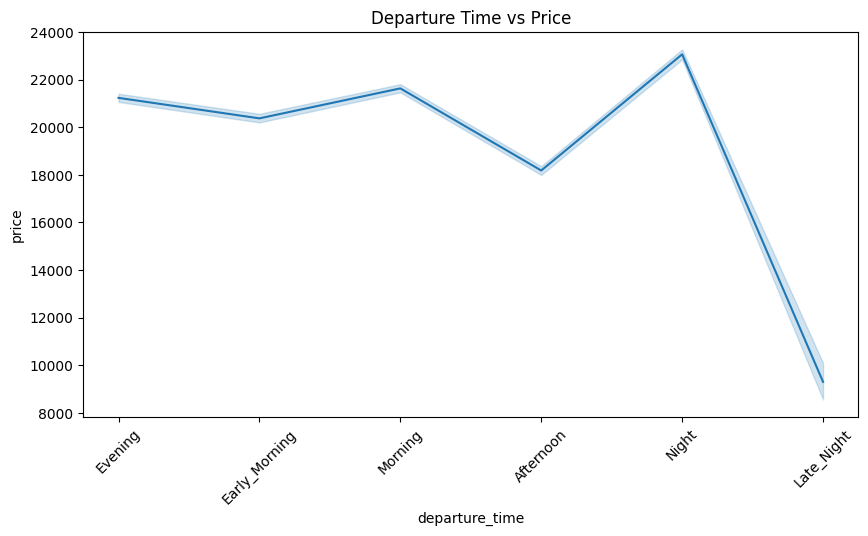

In [92]:
plt.figure(figsize=(10,5))
sns.lineplot(data=df, x='departure_time', y='price')
plt.xticks(rotation=45)
plt.title("Departure Time vs Price")
plt.show()


Departure Time vs Price

Explain the Chart

This line chart shows how ticket prices change across different departure time categories.

What is it Saying?

Certain departure times (like Morning/Evening) tend to have higher average prices, while others (like Night) may be cheaper.
It reveals time‑based pricing patterns.

Features Used

departure_time → categorical time slot (Morning, Afternoon, Evening, Night)

price → numerical value (average price)

What You Are Showing Us

You are showing how flight timing affects ticket cost, helping identify peak hours when prices are higher and off‑peak hours when flights are cheaper.




/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


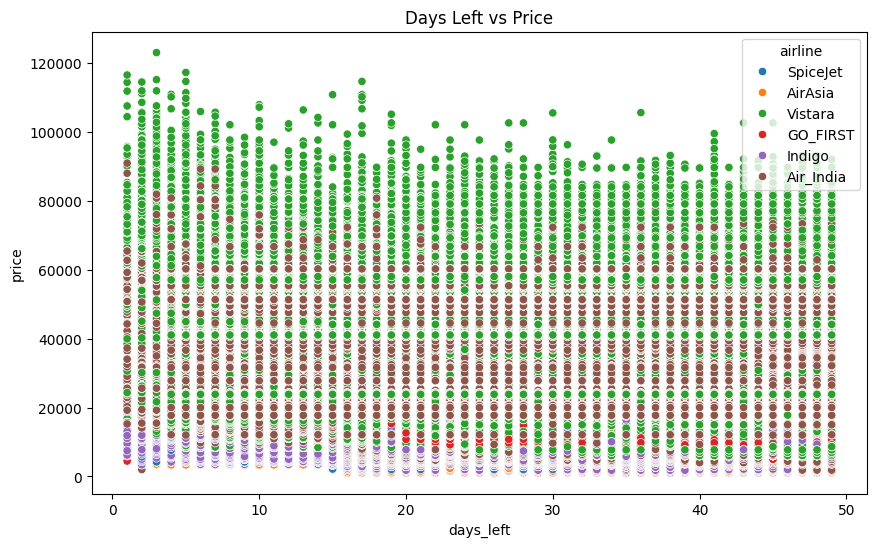

In [93]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='days_left', y='price', hue='airline')
plt.title("Days Left vs Price")
plt.show()


Days Left vs Price (Scatterplot)

Explain the Chart

This scatterplot shows how ticket price changes based on the number of days left before departure.

What is it Saying?

When fewer days are left, prices are higher.
When more days are left, prices are lower.
Different colors show how airlines behave differently.

Features Used

days_left → number of days before the flight

price → ticket cost

airline → color grouping (hue)

What You Are Showing Us?

You are showing that last‑minute bookings are expensive, and early bookings are cheaper.
This proves demand‑based pricing across airlines.

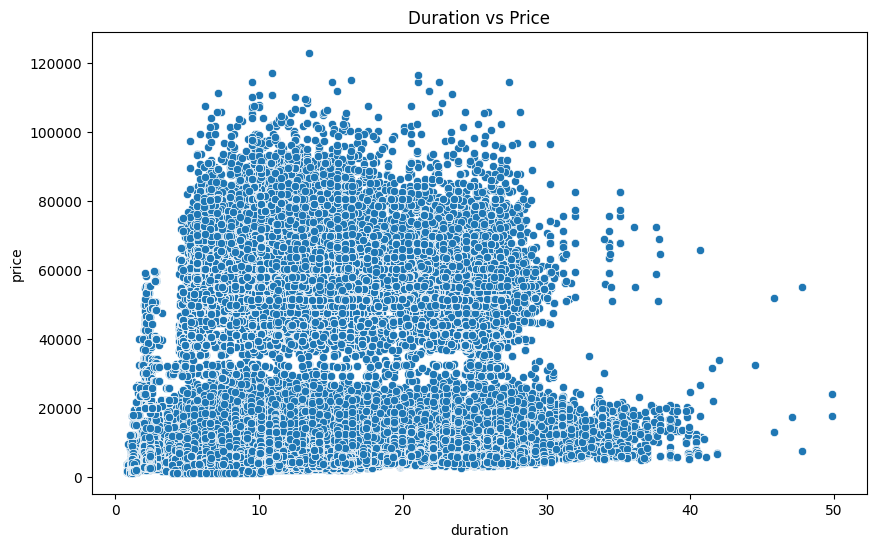

In [94]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='duration', y='price')
plt.title("Duration vs Price")
plt.show()


Duration vs Price (Scatterplot)

Explain the Chart

This scatterplot shows how flight duration affects ticket price.

What is it Saying?

Longer flights generally have higher prices, while shorter flights tend to be cheaper.
Some points appear far above others → long routes or multi‑stop flights cost more.

Features Used
duration → total flight time

price → ticket cost

What You Are Showing Us?

You are showing that flight duration is an important factor in pricing, and longer travel time usually leads to higher fares.


## **Steps to Download your cleaned data for dashboard creation using Power BI**


In [ ]:
from google.colab import files
files.download("cleaned_data.csv")


## Stage 4 – Documentation, Insights and Presentation

Dashboard (Power BI)

Import cleaned CSV
Add all charts (Airline, Class, Stops, Duration, Days Left, Heatmap)
Arrange neatly with slicers
Final dashboard shows all price patterns in one place

Summary of Findings

Premium airlines & business class cost more
Non‑stop flights are expensive
Last‑minute booking increases price
Longer duration → higher price
Some routes are always costly

Key Insights

Early booking reduces price
Class strongly affects ticket cost
Non‑stop flights have a convenience premium
High‑demand routes show higher average prices

Recommendations

Book early
Choose 1‑stop flights for cheaper fares
Airlines can use dynamic pricing
Offer discounts on long‑duration flights

Final Story

Dashboard clearly shows how airline, class, stops, duration, days_left, and route affect price
Patterns explain why some flights are costly
Helps customers save money and airlines optimize pricing


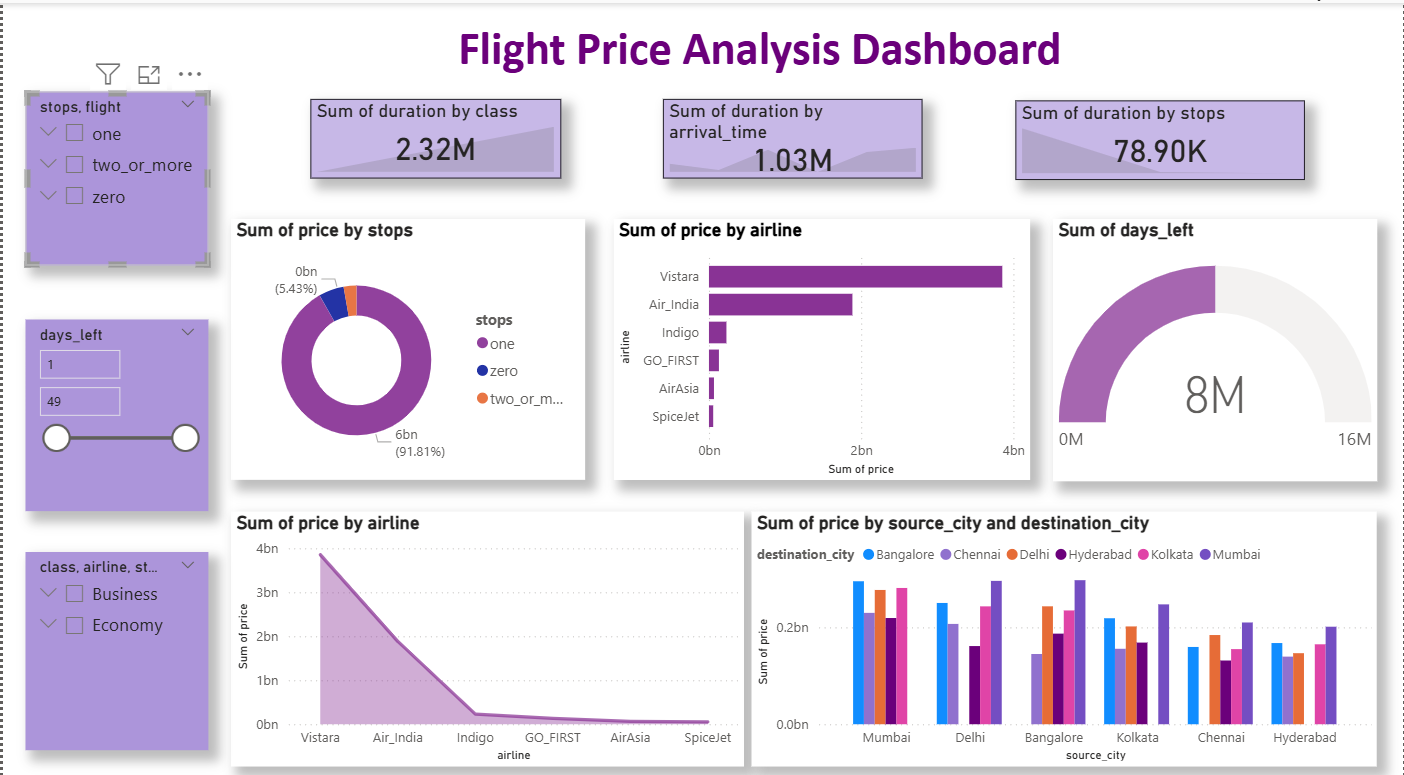

## **Final Overall Insights:**
*Business class, premium airlines, and non‑stop flights cost more.
Prices increase when days_left is low (last‑minute booking).
Long‑duration routes and high‑demand city pairs show higher prices.
Price patterns clearly visible across airline, class, stops, duration, and route.

# Future Enhancement

Use a larger or newer dataset.

Automate analysis with Python scripts.

Add advanced visuals & interactivity in Power BI

Extend to predictive models for price forecasting.

# Conclusion

From the analysis, we found clear patterns in flight pricing. Factors like airline, class, stops, duration, days_left, and route strongly influence ticket cost. The dashboard brings all insights together, showing how prices rise with demand, convenience, and timing. These findings give a solid base for smarter business decisions and better customer planning.